# Importing required libraries

In [1]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow working!")

TensorFlow working!


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.image as mpimg
import random
import pandas as pd
import seaborn as sns
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from itertools import cycle
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [6]:
import os
print(os.getcwd())

c:\Users\Shruthi\Downloads\deep_learning


In [7]:
import os

# Path to Training folder
dataset_path = 'Brain_Tumor_MRI_Dataset/Training'

# Checking the directory structure
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        print(f"{folder}: {len(os.listdir(folder_path))} images")

glioma: 1321 images
meningioma: 1339 images
notumor: 1595 images
pituitary: 1457 images


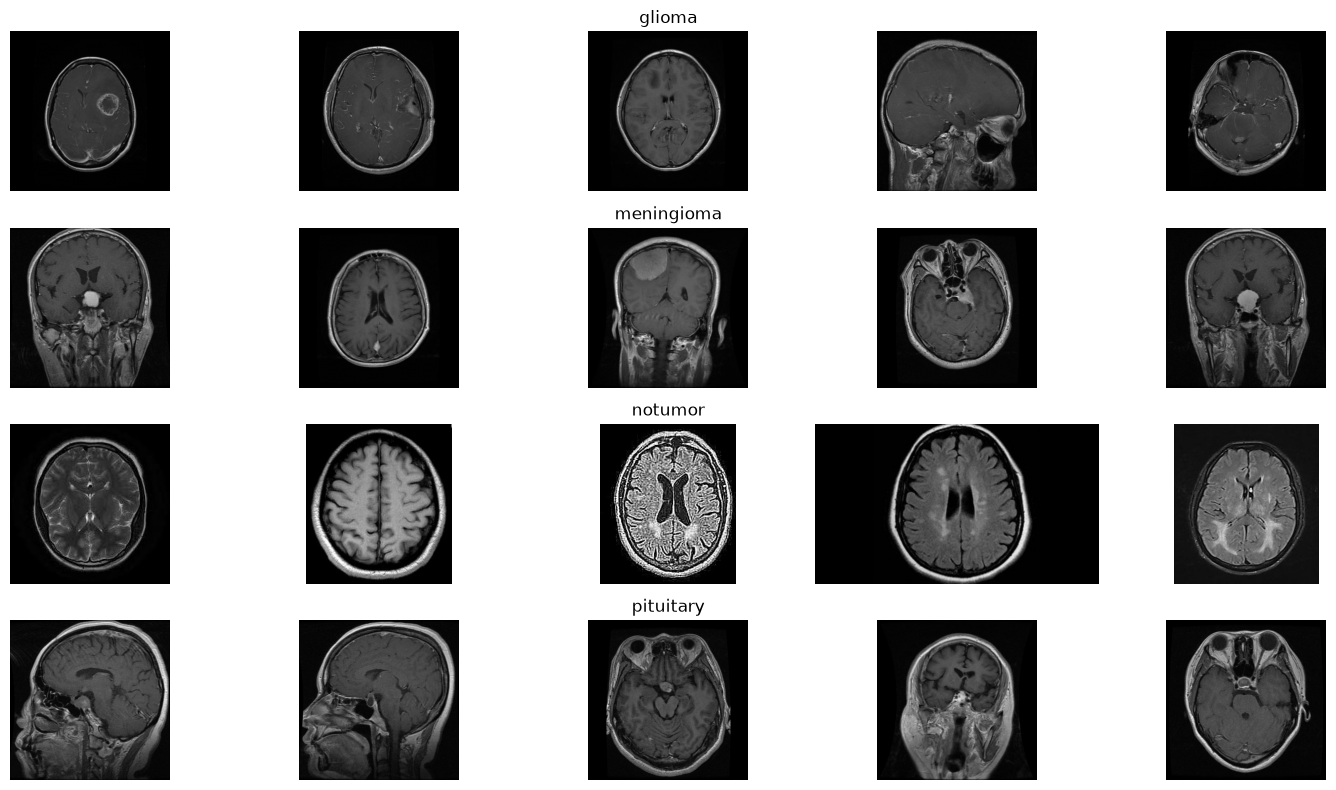

In [8]:
# Setting number of samples per class to display
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
samples_per_class = 5
classes = ['glioma', 'meningioma', 'notumor', 'pituitary']

plt.figure(figsize=(15, 8))

for i, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)
    images = os.listdir(class_path)
    selected_images = random.sample(images, samples_per_class)

    for j, img_name in enumerate(selected_images):
        img_path = os.path.join(class_path, img_name)
        img = mpimg.imread(img_path)

        plt.subplot(len(classes), samples_per_class, i*samples_per_class + j + 1)
        plt.imshow(img, cmap='gray')
        plt.axis('off')
        if j == 2:  # Showing class label in middle image
            plt.title(cls)

plt.tight_layout()
plt.show()


# Exploratory Data Analysis

In [9]:

import pandas as pd
# Creating a dataframe of image counts per class
class_counts = {cls: len(os.listdir(os.path.join(dataset_path, cls))) for cls in classes}
df = pd.DataFrame(list(class_counts.items()), columns=['Class', 'Count'])
print(df)


        Class  Count
0      glioma   1321
1  meningioma   1339
2     notumor   1595
3   pituitary   1457


# Pie chart

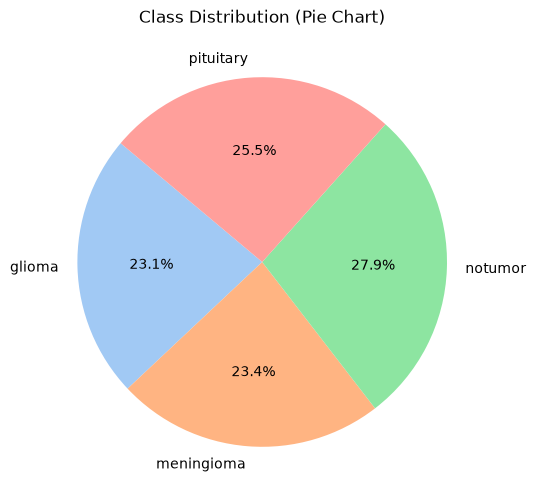

In [10]:
import seaborn as sns
plt.figure(figsize=(6,6))
plt.pie(df['Count'], labels=df['Class'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Class Distribution (Pie Chart)')
plt.show()

# Bar ploting

C:\Users\Shruthi\AppData\Local\Temp\ipykernel_4756\3964083244.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Class', y='Count', data=df, palette='pastel')


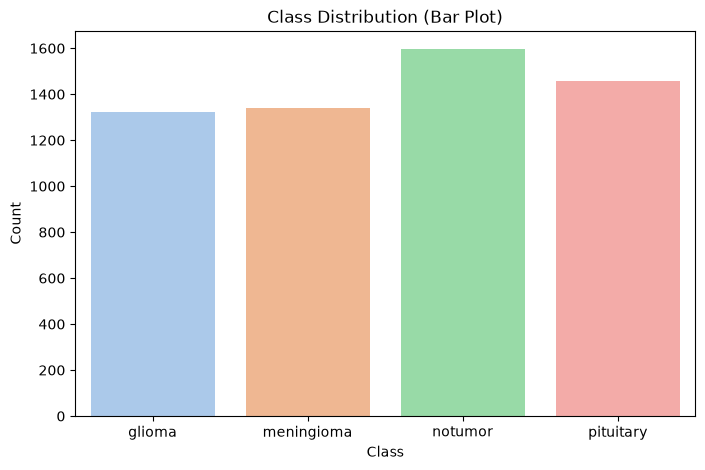

In [11]:

plt.figure(figsize=(8,5))
sns.barplot(x='Class', y='Count', data=df, palette='pastel')
plt.title('Class Distribution (Bar Plot)')
plt.show()

# Line plot

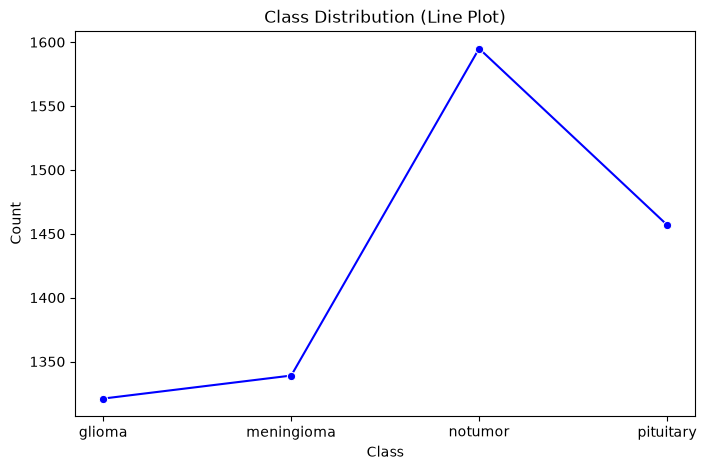

In [12]:

plt.figure(figsize=(8,5))
sns.lineplot(x='Class', y='Count', data=df, marker='o', color='blue')
plt.title('Class Distribution (Line Plot)')
plt.show()

# Data Preprocessing and Augmentation

In [13]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [14]:
import sys
print(sys.executable)


c:\Users\Shruthi\miniconda3\envs\dl_env\python.exe


In [15]:
import torch
print(torch.__version__)

2.12.1+cpu


In [16]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# Image size and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Path to your Training folder
dataset_path = "Brain_Tumor_MRI_Dataset/Training"

# Data augmentation and preprocessing
transform = transforms.Compose([
    transforms.Resize((IMG_HEIGHT, IMG_WIDTH)),
    transforms.RandomRotation(25),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2), shear=10),
    transforms.ToTensor()
])

# Load dataset
dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

# Split dataset into 80% train and 20% validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, validation_dataset = random_split(dataset, [train_size, val_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Print class indices
print("Class indices:", dataset.class_to_idx)

# Print number of images
print("Training images:", len(train_dataset))
print("Validation images:", len(validation_dataset))

Class indices: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
Training images: 4569
Validation images: 1143


# Transfer Learning with MobileNetV2

In [17]:
import torch
import torchvision
import sklearn
import matplotlib
import seaborn
import numpy as np

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Seaborn:", seaborn.__version__)

Torch: 2.12.1+cpu
Torchvision: 0.27.1+cpu
Scikit-learn: 1.9.0
Matplotlib: 3.11.0
Seaborn: 0.13.2


In [18]:
import sys
print(sys.executable)

c:\Users\Shruthi\miniconda3\envs\dl_env\python.exe


In [19]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)
print(torch.cuda.is_available())

2.12.1+cpu
0.27.1+cpu
False


In [20]:
from torchvision import models

model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

print("MobileNetV2 loaded successfully!")

MobileNetV2 loaded successfully!


In [21]:
import os

dataset_path = "Brain_Tumor_MRI_Dataset/Training"

print(os.path.exists(dataset_path))

True


Using: cpu
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Training Images: 4569
Validation Images: 1143

Starting Training...

Epoch [1/9] | Train Accuracy: 54.59% | Validation Accuracy: 78.13%
Best Model Saved (Validation Accuracy = 78.13%)
Epoch [2/9] | Train Accuracy: 65.24% | Validation Accuracy: 77.34%
Epoch [3/9] | Train Accuracy: 67.19% | Validation Accuracy: 79.44%
Best Model Saved (Validation Accuracy = 79.44%)
Epoch [4/9] | Train Accuracy: 68.83% | Validation Accuracy: 80.14%
Best Model Saved (Validation Accuracy = 80.14%)
Epoch [5/9] | Train Accuracy: 69.16% | Validation Accuracy: 80.14%
Epoch [6/9] | Train Accuracy: 69.64% | Validation Accuracy: 80.23%
Best Model Saved (Validation Accuracy = 80.23%)
Epoch [7/9] | Train Accuracy: 68.79% | Validation Accuracy: 82.15%
Best Model Saved (Validation Accuracy = 82.15%)
Epoch [8/9] | Train Accuracy: 69.99% | Validation Accuracy: 83.03%
Best Model Saved (Validation Accuracy = 83.03%)
Epoch [9/9] | Train Accuracy: 70.34% |

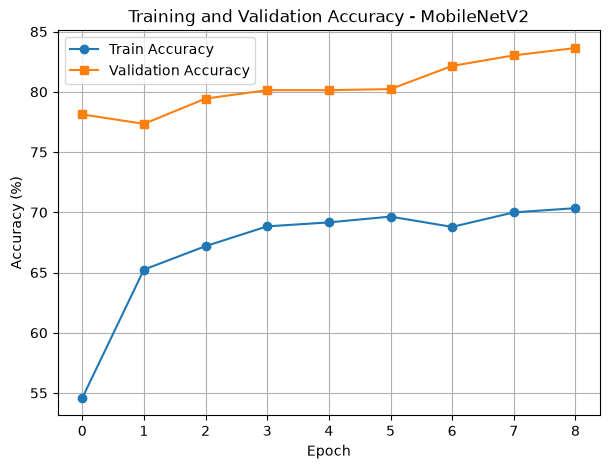

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import gc

# Free unused memory
gc.collect()

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

# Dataset path
dataset_path = "Brain_Tumor_MRI_Dataset/Training"

# Image transformations
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

# Load dataset
dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

# Split dataset (80% Train, 20% Validation)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

print("Classes:", dataset.classes)
print("Training Images:", len(train_dataset))
print("Validation Images:", len(val_dataset))

# Load MobileNetV2
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# Freeze feature extractor
for param in model.features.parameters():
    param.requires_grad = False

# Replace classifier
model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.last_channel, 128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 4)
)

model = model.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.0001)

# Training Settings
num_epochs = 9
best_acc = 0

train_acc_history = []
val_acc_history = []

print("\nStarting Training...\n")

for epoch in range(num_epochs):

    # ------------------ Training ------------------
    model.train()

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_acc = 100 * correct / total
    train_acc_history.append(train_acc)

    # ---------------- Validation ------------------
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    val_acc_history.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Accuracy: {train_acc:.2f}% | Validation Accuracy: {val_acc:.2f}%")

    # Save Best Model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(f"Best Model Saved (Validation Accuracy = {best_acc:.2f}%)")

print("\nTraining Completed!")
print(f"Best Validation Accuracy: {best_acc:.2f}%")

# Plot Accuracy
plt.figure(figsize=(7,5))
plt.plot(train_acc_history, marker='o', label="Train Accuracy")
plt.plot(val_acc_history, marker='s', label="Validation Accuracy")
plt.title("Training and Validation Accuracy - MobileNetV2")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()


Classification Report:

              precision    recall  f1-score   support

      glioma       0.79      0.77      0.78       256
  meningioma       0.69      0.57      0.62       245
     notumor       0.93      0.93      0.93       347
   pituitary       0.80      0.94      0.86       295

    accuracy                           0.82      1143
   macro avg       0.80      0.80      0.80      1143
weighted avg       0.81      0.82      0.81      1143



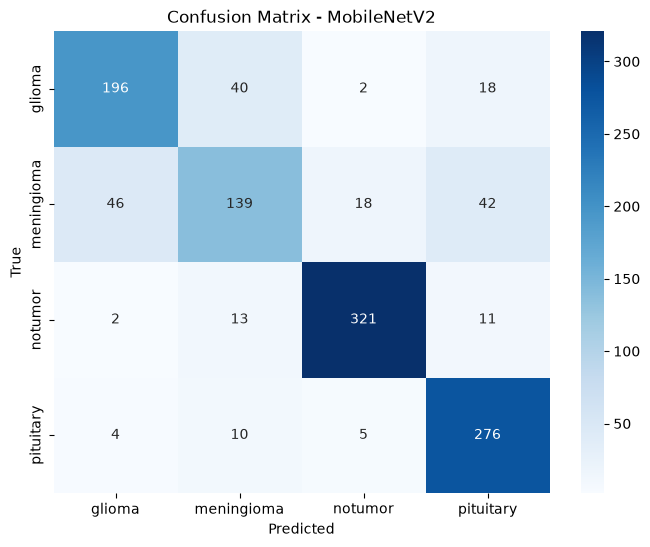

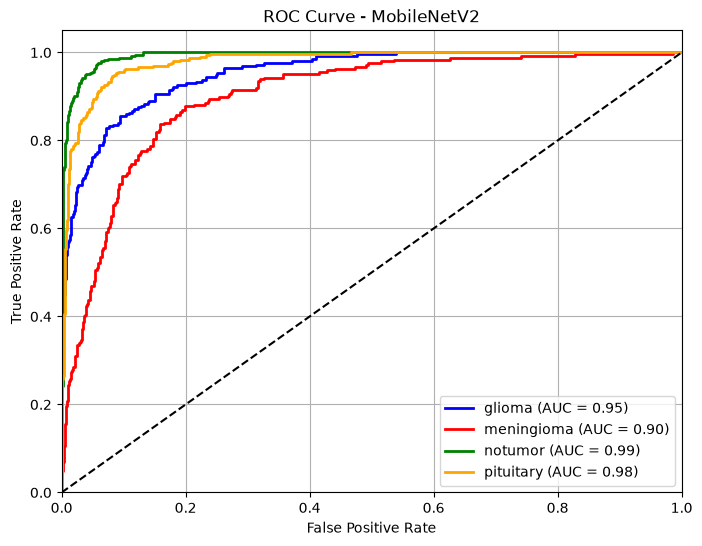

In [23]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize
from itertools import cycle

# Load best model
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

# Store predictions
Y_true = []
Y_pred = []
Y_pred_prob = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        _, predicted = torch.max(outputs, 1)

        Y_true.extend(labels.cpu().numpy())
        Y_pred.extend(predicted.cpu().numpy())
        Y_pred_prob.extend(probs.cpu().numpy())

Y_true = np.array(Y_true)
Y_pred = np.array(Y_pred)
Y_pred_prob = np.array(Y_pred_prob)

# ---------------- Classification Report ----------------

print("\nClassification Report:\n")

print(
    classification_report(
        Y_true,
        Y_pred,
        target_names=dataset.classes
    )
)

# ---------------- Confusion Matrix ----------------

cm = confusion_matrix(Y_true, Y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - MobileNetV2")
plt.show()

# ---------------- ROC Curve ----------------

Y_true_bin = label_binarize(Y_true, classes=[0,1,2,3])

fpr = {}
tpr = {}
roc_auc = {}

for i in range(4):

    fpr[i], tpr[i], _ = roc_curve(
        Y_true_bin[:, i],
        Y_pred_prob[:, i]
    )

    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))

colors = cycle(["blue","red","green","orange"])

for i, color in zip(range(4), colors):

    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f"{dataset.classes[i]} (AUC = {roc_auc[i]:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlim([0,1])
plt.ylim([0,1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - MobileNetV2")

plt.legend(loc="lower right")
plt.grid(True)

plt.show()

#   EfficientNetB0 Model

In [25]:
import torch
import torch.nn as nn
from torchvision import models

# Classification Report

In [27]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [33]:
import torch
import numpy as np
from sklearn.metrics import classification_report

# Put model in evaluation mode
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Print Classification Report
print("="*60)
print("Classification Report - EfficientNetB0")
print("="*60)

print(classification_report(
    y_true,
    y_pred,
    target_names=dataset.classes,
    digits=2
))

Classification Report - EfficientNetB0
              precision    recall  f1-score   support

      glioma       0.81      0.77      0.79       256
  meningioma       0.71      0.62      0.66       245
     notumor       0.92      0.92      0.92       347
   pituitary       0.81      0.93      0.87       295

    accuracy                           0.83      1143
   macro avg       0.81      0.81      0.81      1143
weighted avg       0.82      0.83      0.82      1143



# Confusion Matrix

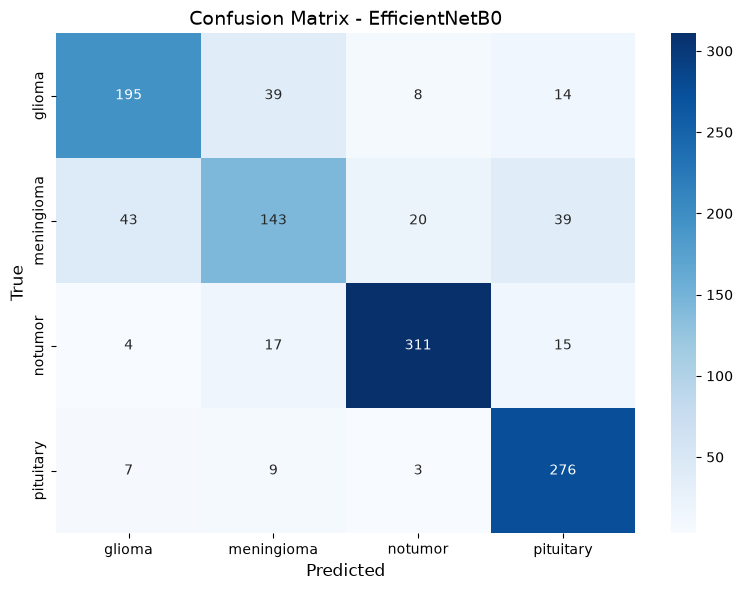

In [34]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# -----------------------------
# Evaluate model on validation set
# -----------------------------
model.eval()

Y_true = []
Y_pred = []

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        Y_true.extend(labels.cpu().numpy())
        Y_pred.extend(predicted.cpu().numpy())

Y_true = np.array(Y_true)
Y_pred = np.array(Y_pred)

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(Y_true, Y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.title("Confusion Matrix - EfficientNetB0", fontsize=14)

plt.tight_layout()
plt.show()

#  ROC Curve

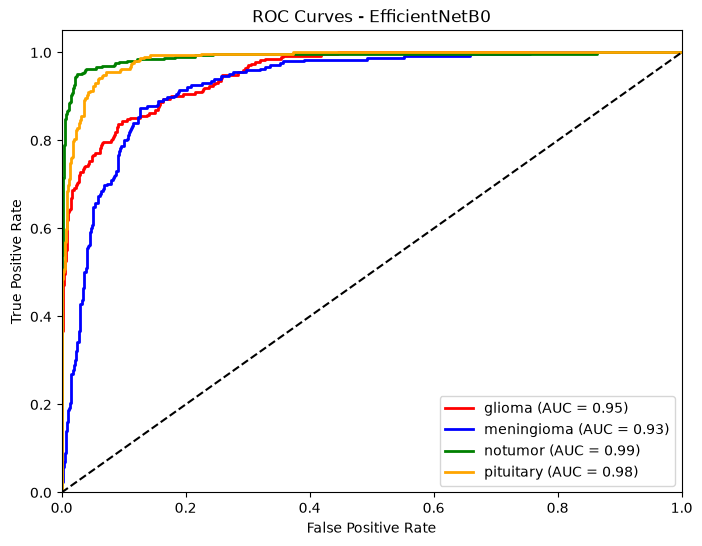

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from itertools import cycle
import matplotlib.pyplot as plt
import numpy as np
import torch

# Get probabilities and true labels
y_true = []
y_pred_prob = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

# Convert labels to binary format
y_true_bin = label_binarize(y_true, classes=[0,1,2,3])
n_classes = y_true_bin.shape[1]

# Compute ROC and AUC
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(8,6))
colors = cycle(['red', 'blue', 'green', 'orange'])

for i, color in zip(range(n_classes), colors):
    plt.plot(
        fpr[i],
        tpr[i],
        color=color,
        lw=2,
        label=f'{dataset.classes[i]} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0,1], [0,1], 'k--')
plt.xlim([0,1])
plt.ylim([0,1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - EfficientNetB0')
plt.legend(loc='lower right')
plt.show()